# Import

In [2]:
import time
from time import sleep, monotonic
import datetime
import numpy as np
import matplotlib.pyplot as plt
import sys
import pyvisa
import qcodes as qc
from qcodes.dataset import Measurement
from qcodes.dataset import do0d
from qcodes.dataset.experiment_container import new_experiment, load_experiment_by_name
from qcodes.dataset.plotting import plot_by_id
from qcodes.dataset.data_set import load_by_id, load_by_counter
from qcodes import initialise_or_create_database_at, new_data_set, new_experiment
from qcodes.station import Station
initialise_or_create_database_at("./2026-03-10_SNSPD4.db")
from functions import osc_set_standard, osc_check_standard, capture_trace, capture_trace_simple
from functions import snspd_dark_counts, make_title
import snspd
params = snspd.snspd()

# Set up experiment
exp_name = 'SNSPD4_23_03_2026'
sample_name = '00'

try:
    exp = qc.load_experiment_by_name(exp_name, sample=sample_name)
    print('Experiment loaded. Last ID no:', exp.last_counter)
except ValueError:
    exp = new_experiment(exp_name, sample_name)
    print('Started new experiment')

Experiment loaded. Last ID no: 472


In [6]:
ID = 465
data = load_by_id(ID).get_parameter_data()
photon_flux = data['Nphotons']['Nphotons'] # this is a rate, Nphotons/sec
wavelength_range = data['wavelength_range']['wavelength_range'] # this is a rate, Nphotons/sec

In [3]:
ID = 457
data = load_by_id(ID).get_parameter_data()
idx = 26 # ID corresponding to 4.7V attenuation, ~99.2dB total
print(data['v_attenuator']['v_attenuator'][idx])
print(data['total_attenuation']['total_attenuation'][idx])

# Photon flux for each wavelength 
ID = 465
data = load_by_id(ID).get_parameter_data()
photon_flux = data['Nphotons']['Nphotons'] # this is a rate, Nphotons/sec

# Use dark counts value from Measurement 4-1
ID = 455
data = load_by_id(ID).get_parameter_data()
dark_count_rate1 = data['CR1']['CR1'][0]
dark_count_rate2 = data['CR2']['CR2'][0]

# light count rate vs wavelength from Measurement 4-2
ID = 472
data = load_by_id(ID).get_parameter_data()
light_count_rate1 = data['CR1']['CR1'][~np.isnan(data['CR1']['CR1'])]
light_count_rate2 = data['CR2']['CR2'][~np.isnan(data['CR2']['CR2'])]
wavelength = data['wavelength_range']['wavelength_range'][~np.isnan(data['wavelength_range']['wavelength_range'])]*1e9 # convert to nm

4.7
99.1683535121345


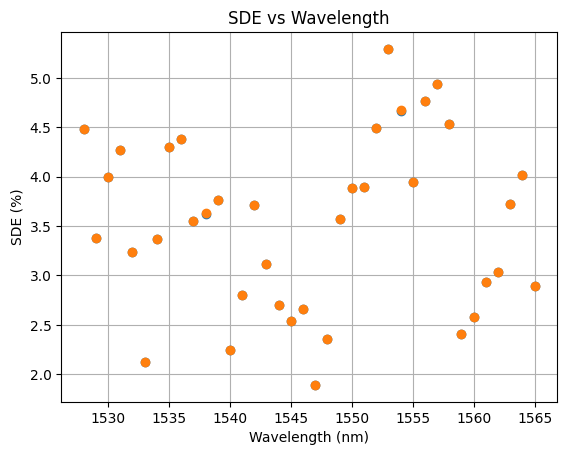

In [20]:
SDE1 = 100*(light_count_rate1-dark_count_rate1)/photon_flux
SDE2 = 100*(light_count_rate2-dark_count_rate2)/photon_flux

title = f'SDE vs Wavelength'

plt.plot(wavelength, SDE1, 'o', label='Threshold 1 (HIGH)')
plt.plot(wavelength, SDE2, 'o', label='Threshold 2 (HIGH)')
plt.title(title)
plt.ylabel('SDE (%)')
# plt.xlabel('Total Attenuation (dB)')
plt.xlabel('Wavelength (nm)')
plt.grid()

Text(0.5, 1.0, 'Measured Rate vs Expected')

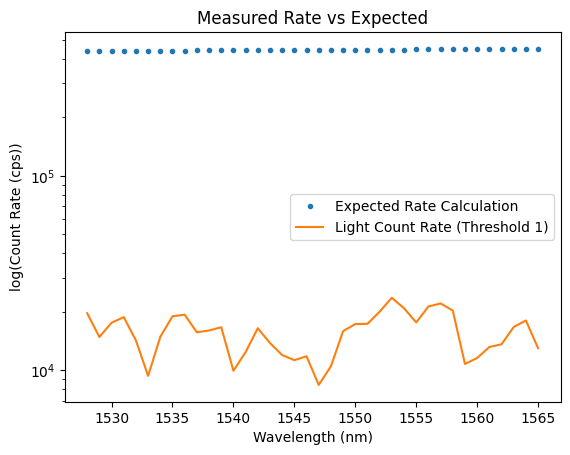

In [19]:
plt.semilogy(wavelength, photon_flux, '.', label='Expected Rate Calculation')
plt.semilogy(wavelength, light_count_rate1, label='Light Count Rate (Threshold 1)')

plt.legend()
plt.ylabel('log(Count Rate (cps))')
plt.xlabel(f'Wavelength (nm)')
plt.title('Measured Rate vs Expected')